In [1]:
# Step 0: Install Required Libraries
# These libraries are required to create, simulate, and visualize quantum circuits.
!pip install qiskit matplotlib pylatexenc --quiet

In [2]:
# Step 1: Import Libraries
# Import the main Qiskit components for circuit creation and visualization.
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

=== Step 0: Initial 5-Qubit State ===


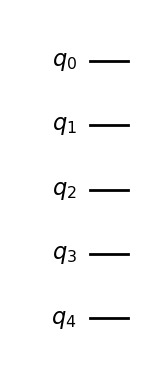

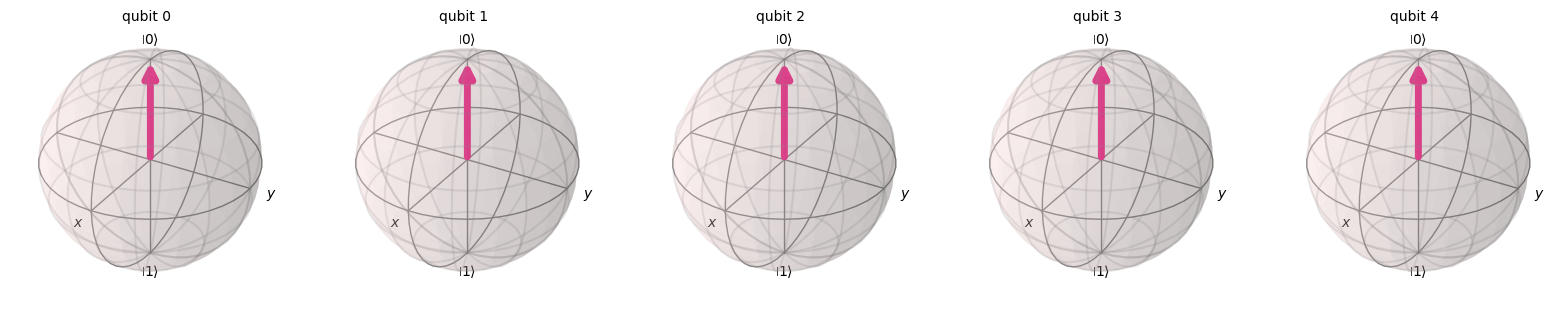

In [3]:
# Step 2: Initialize a 5-Qubit Quantum Circuit
n = 5  # Number of qubits for QFT
qc = QuantumCircuit(n)

print("=== Step 0: Initial 5-Qubit State ===")

# Display the empty initial quantum circuit
display(qc.draw('mpl'))

# Visualize the initial Bloch vector (all qubits in |0⟩ state)
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


=== Step 1: Applying Quantum Fourier Transform ===
Applied Hadamard (H) gate on qubit 0


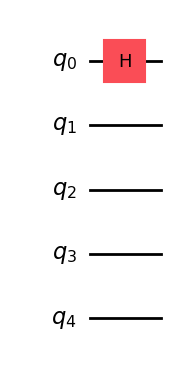

Controlled Phase (CP) rotation between qubit 1 → 0 with angle = 1.571 rad


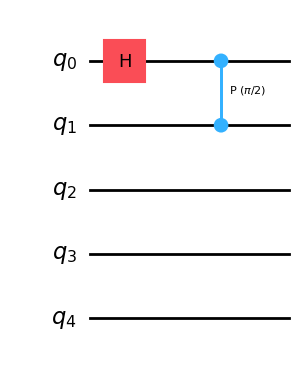

Controlled Phase (CP) rotation between qubit 2 → 0 with angle = 0.785 rad


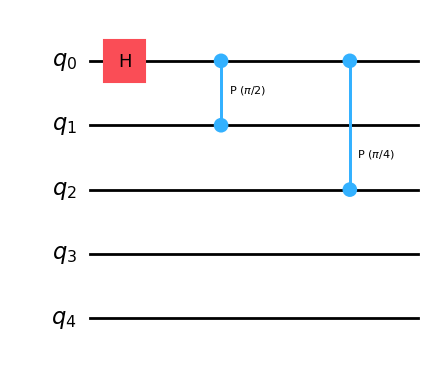

Controlled Phase (CP) rotation between qubit 3 → 0 with angle = 0.393 rad


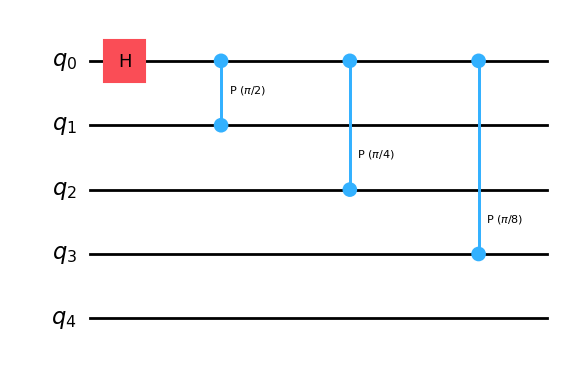

Controlled Phase (CP) rotation between qubit 4 → 0 with angle = 0.196 rad


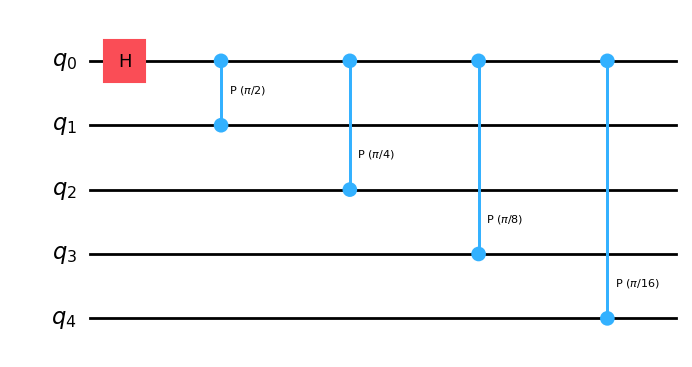

Applied Hadamard (H) gate on qubit 1


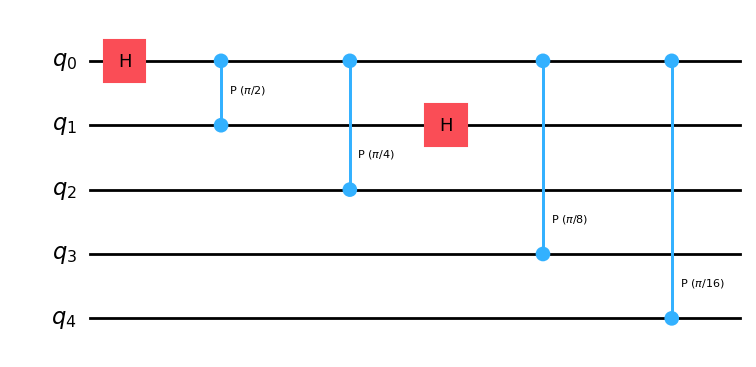

Controlled Phase (CP) rotation between qubit 2 → 1 with angle = 1.571 rad


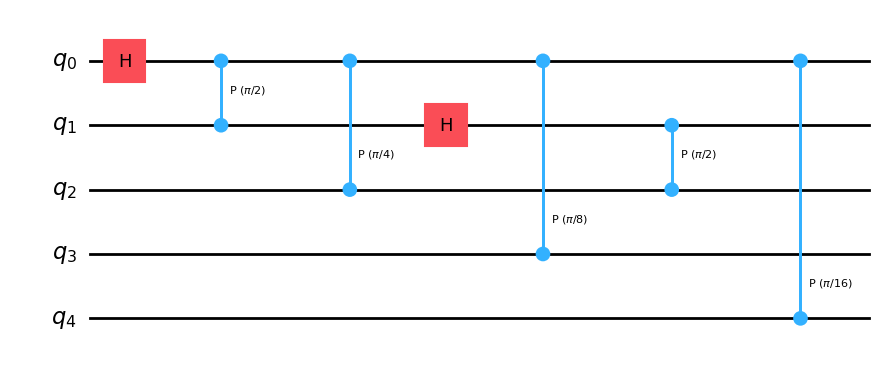

Controlled Phase (CP) rotation between qubit 3 → 1 with angle = 0.785 rad


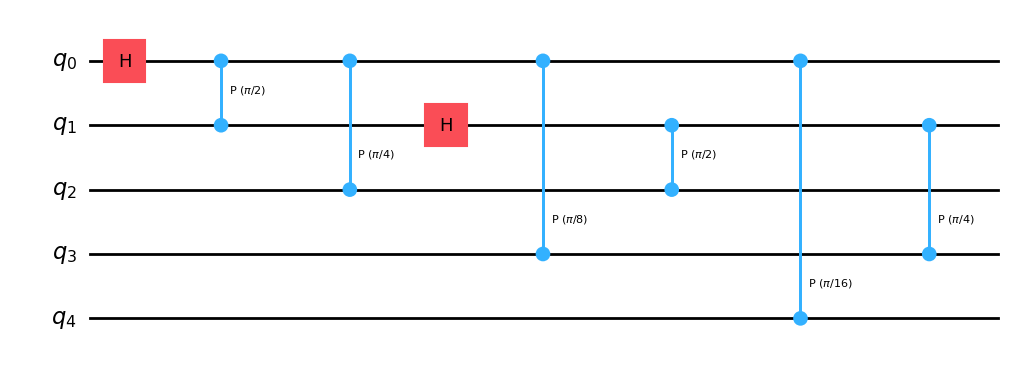

Controlled Phase (CP) rotation between qubit 4 → 1 with angle = 0.393 rad


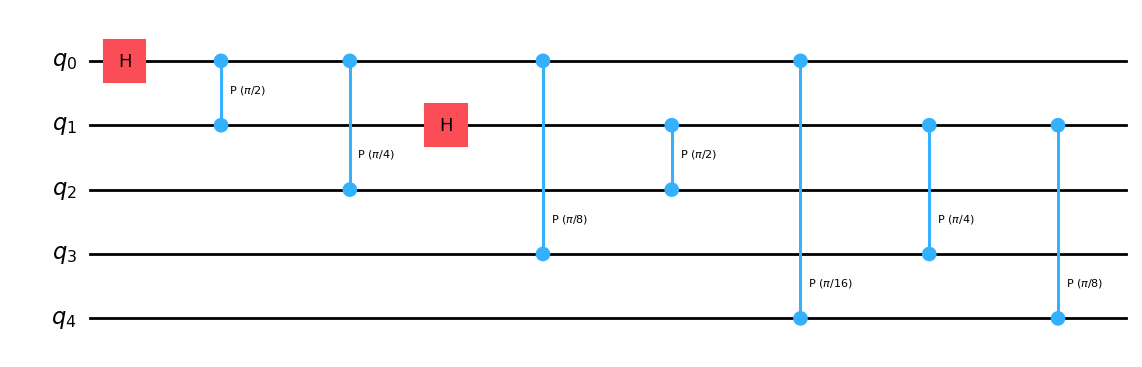

Applied Hadamard (H) gate on qubit 2


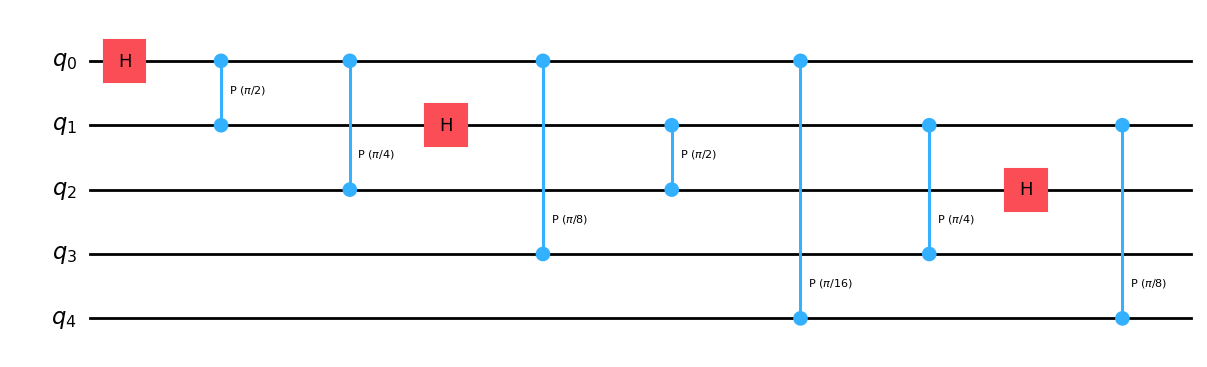

Controlled Phase (CP) rotation between qubit 3 → 2 with angle = 1.571 rad


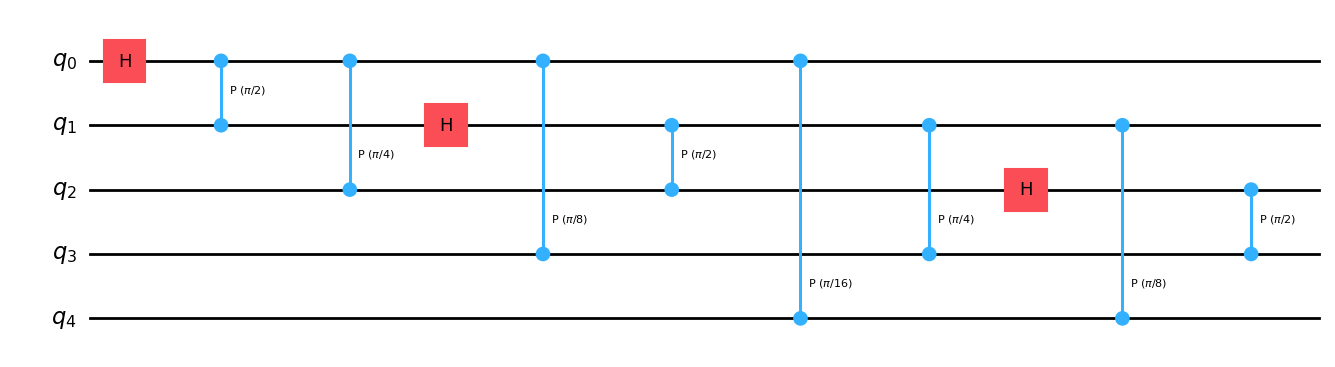

Controlled Phase (CP) rotation between qubit 4 → 2 with angle = 0.785 rad


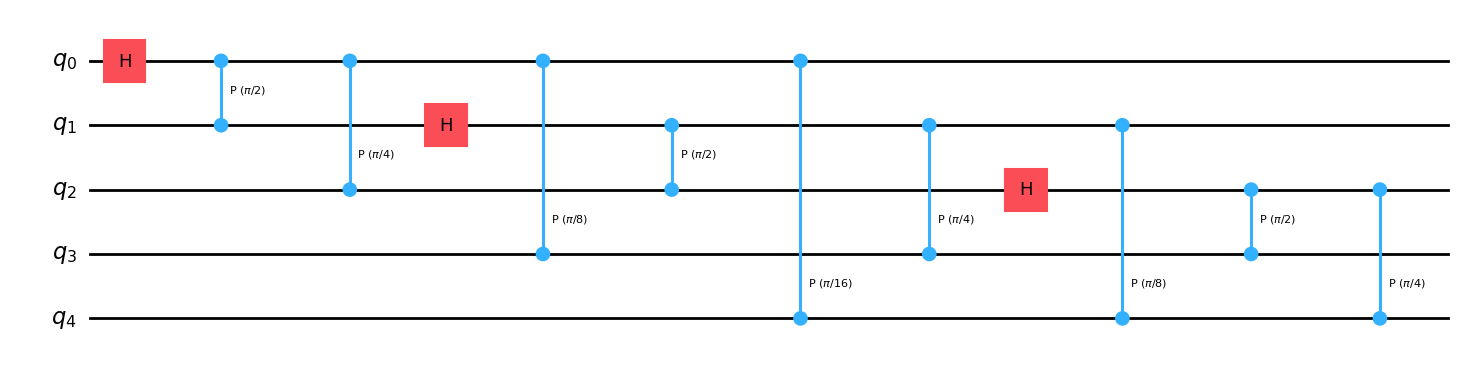

Applied Hadamard (H) gate on qubit 3


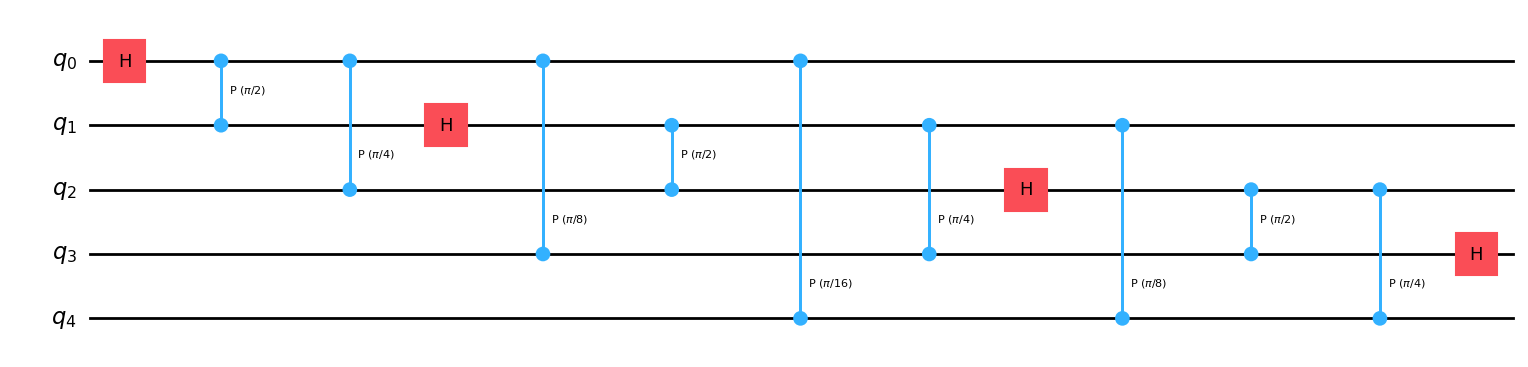

Controlled Phase (CP) rotation between qubit 4 → 3 with angle = 1.571 rad


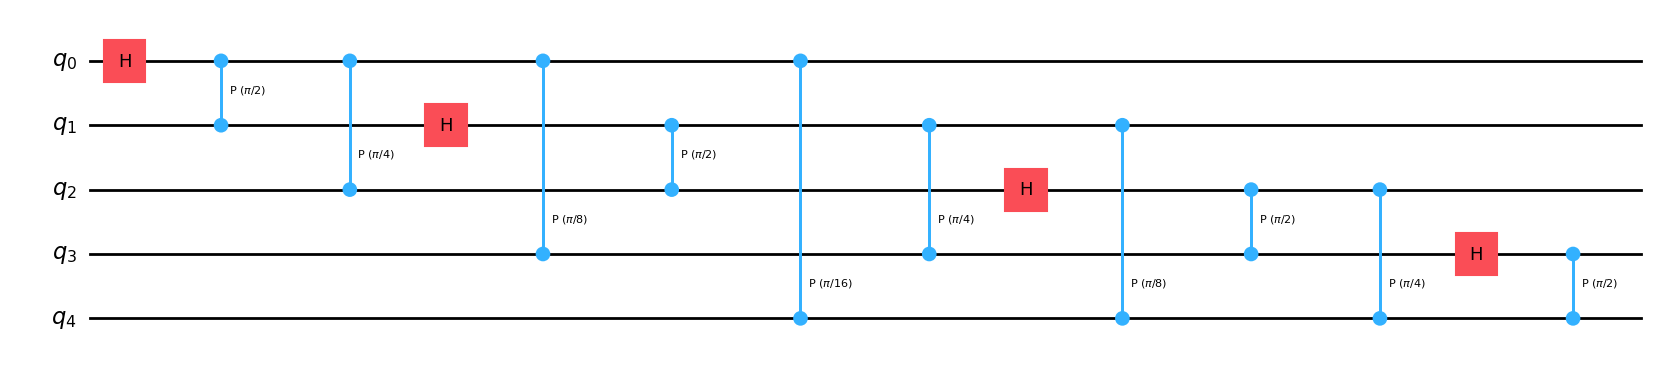

Applied Hadamard (H) gate on qubit 4


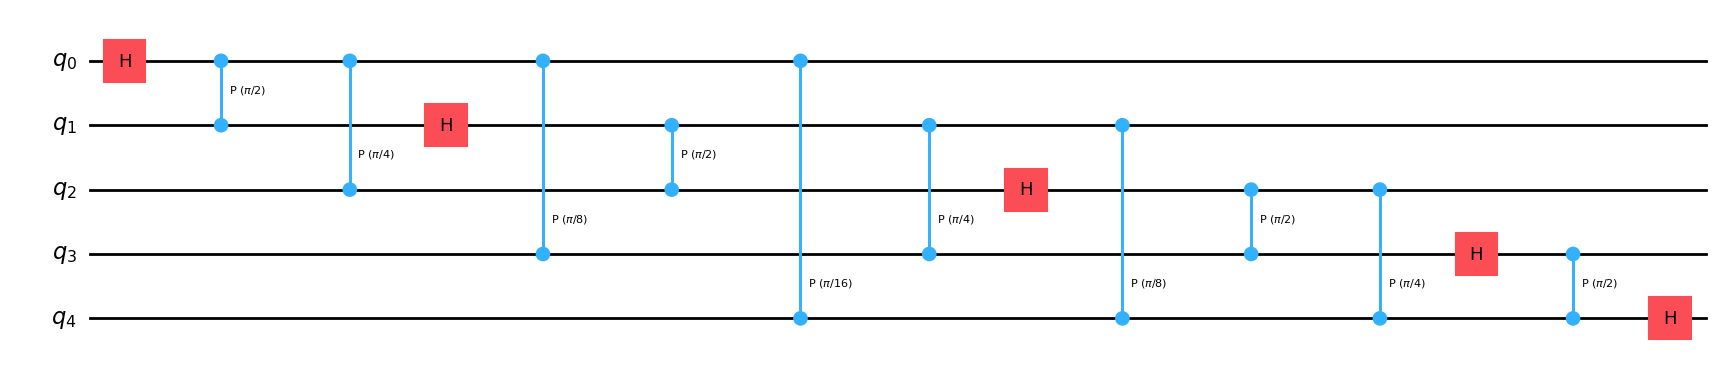

In [4]:
# Step 3: Apply Quantum Fourier Transform (QFT)
print("\n=== Step 1: Applying Quantum Fourier Transform ===")

# The QFT consists of Hadamard + controlled phase gates in sequence
for j in range(n):
    # Step 3a: Apply Hadamard gate to qubit j
    qc.h(j)
    print(f"Applied Hadamard (H) gate on qubit {j}")
    display(qc.draw('mpl'))

    # Show Bloch vector after applying Hadamard
    state = Statevector.from_instruction(qc)
    plot_bloch_multivector(state)
    plt.show()

    # Step 3b: Apply Controlled Phase Rotations between qubits
    for k in range(2, n - j + 1):
        angle = np.pi / (2 ** (k - 1))
        if j + k - 1 < n:
            qc.cp(angle, j + k - 1, j)
            print(f"Controlled Phase (CP) rotation between qubit {j + k - 1} → {j} with angle = {round(angle, 3)} rad")
            display(qc.draw('mpl'))

            # Show Bloch vector after controlled phase rotation
            state = Statevector.from_instruction(qc)
            plot_bloch_multivector(state)
            plt.show()


=== Step 2: Applying SWAP Gates to Reverse Qubit Order ===
Swapped qubit 0 ↔ qubit 4


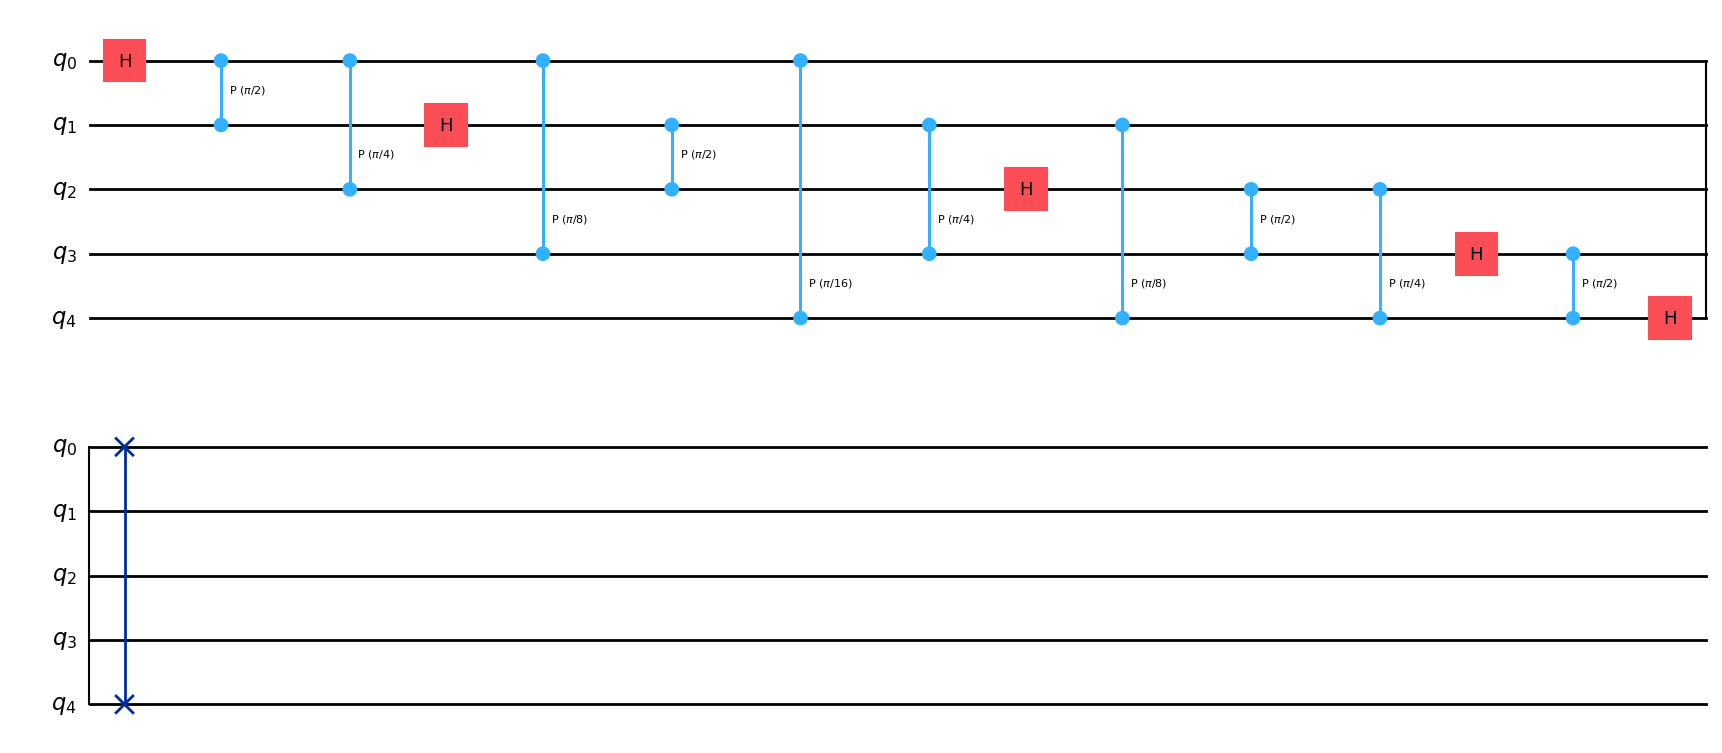

Swapped qubit 1 ↔ qubit 3


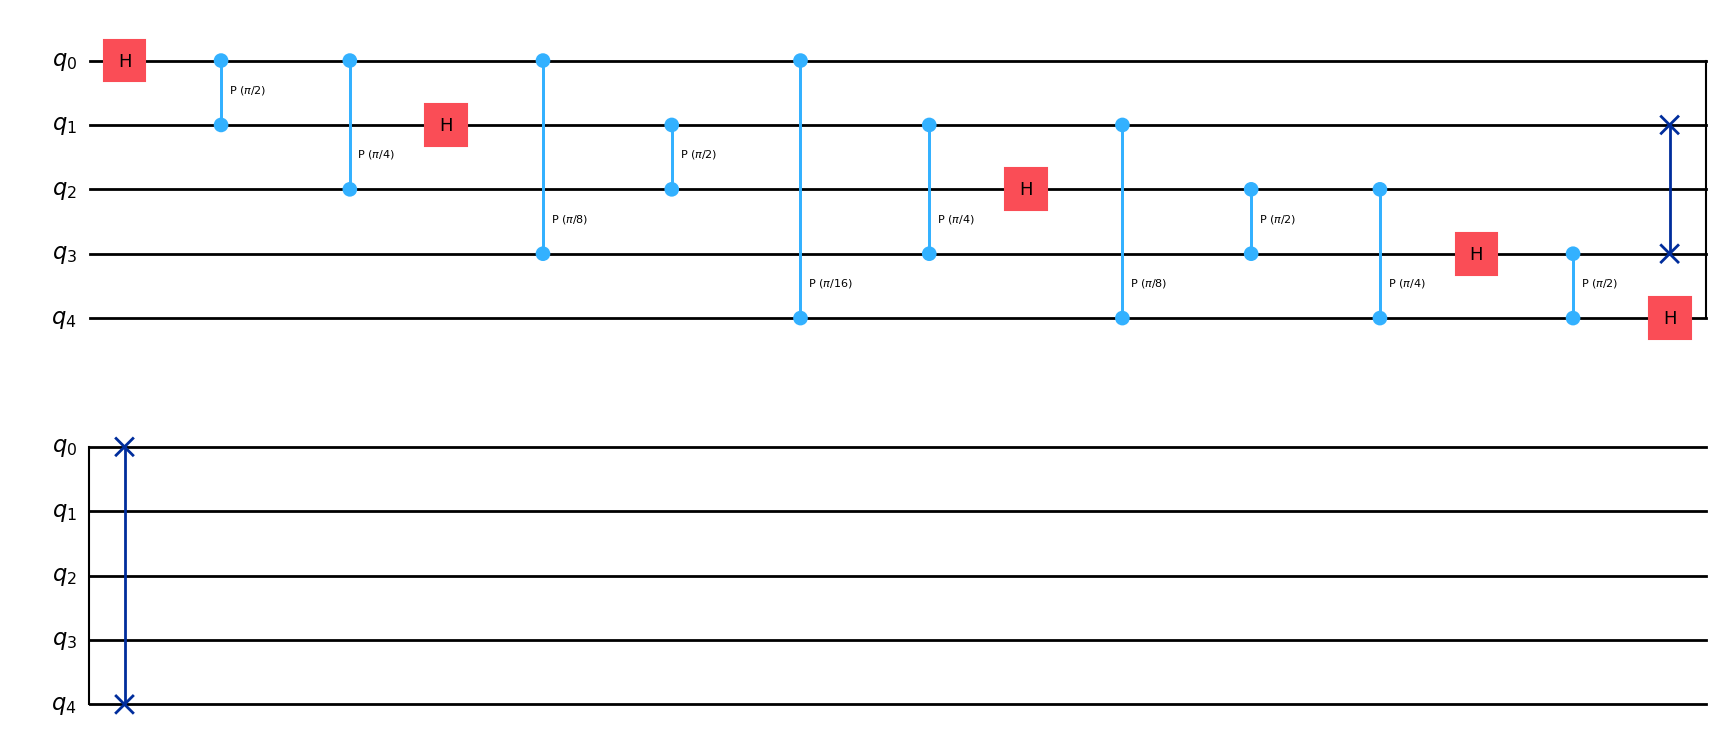

In [5]:
# Step 4: Swap Qubits to Reverse Order (QFT Output Step)
print("\n=== Step 2: Applying SWAP Gates to Reverse Qubit Order ===")

# The final step of QFT is to reverse the order of qubits
for i in range(n // 2):
    qc.swap(i, n - i - 1)
    print(f"Swapped qubit {i} ↔ qubit {n - i - 1}")
    display(qc.draw('mpl'))

    # Visualize state after each SWAP operation
    state = Statevector.from_instruction(qc)
    plot_bloch_multivector(state)
    plt.show()



=== Step 3: Applying Random RY and RZ Rotations for Benchmarking ===
Applied RY(0.59) and RZ(1.49) on qubit 0


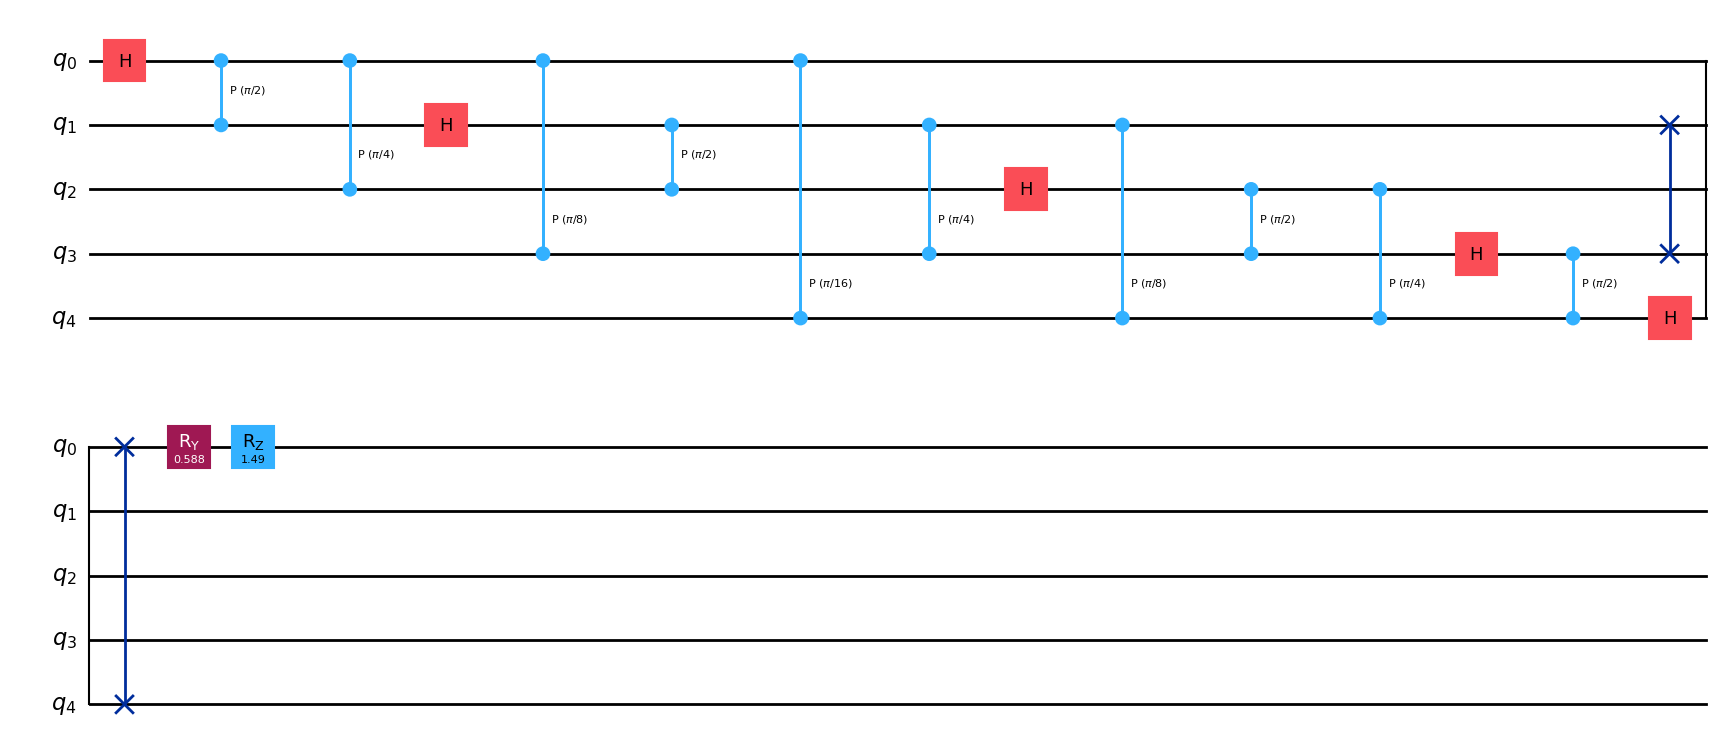

Applied RY(1.15) and RZ(0.94) on qubit 1


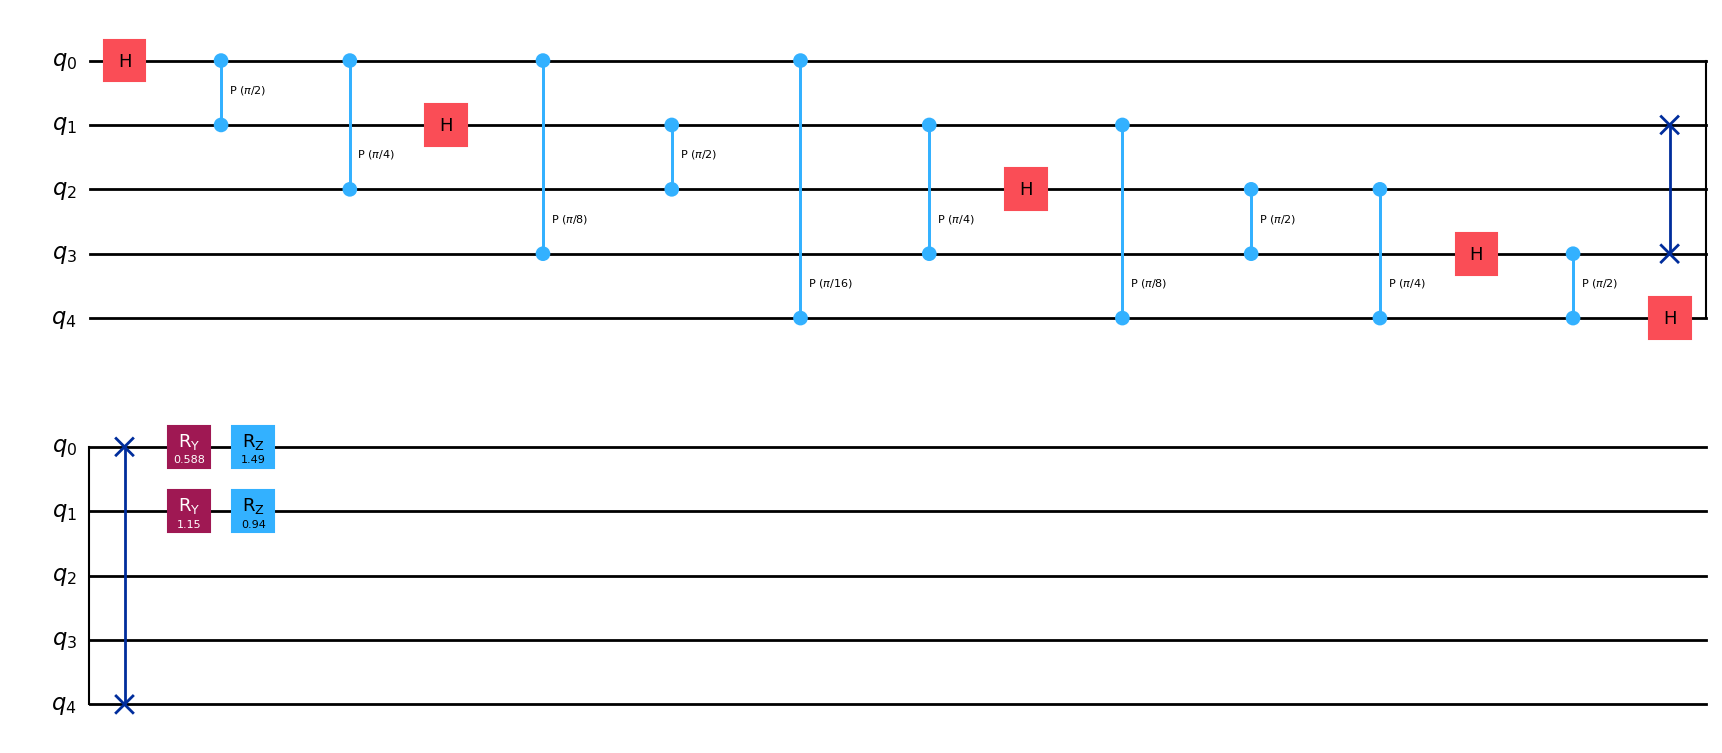

Applied RY(0.25) and RZ(0.25) on qubit 2


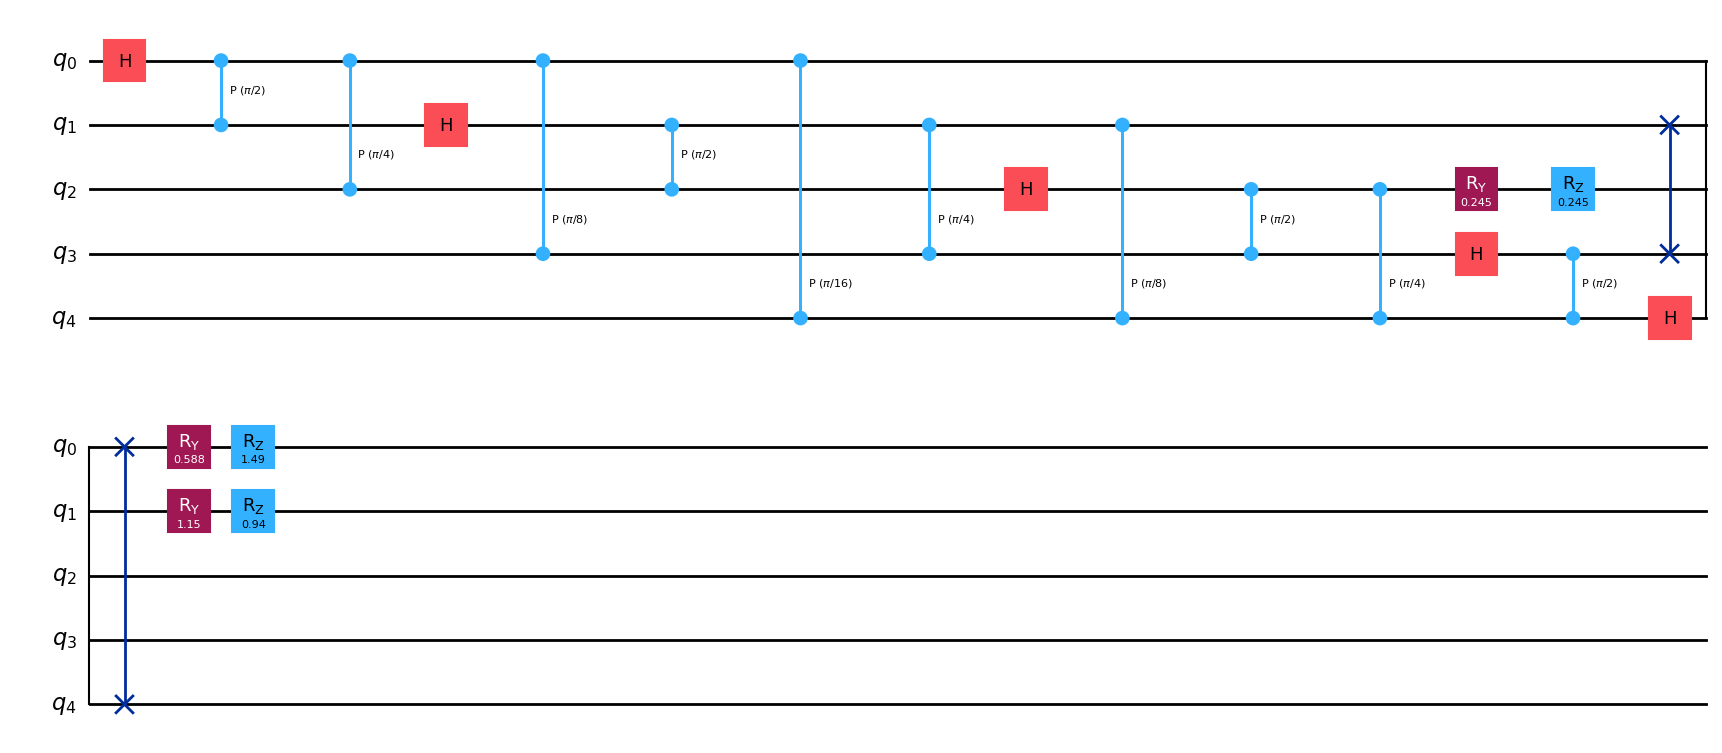

Applied RY(0.09) and RZ(1.36) on qubit 3


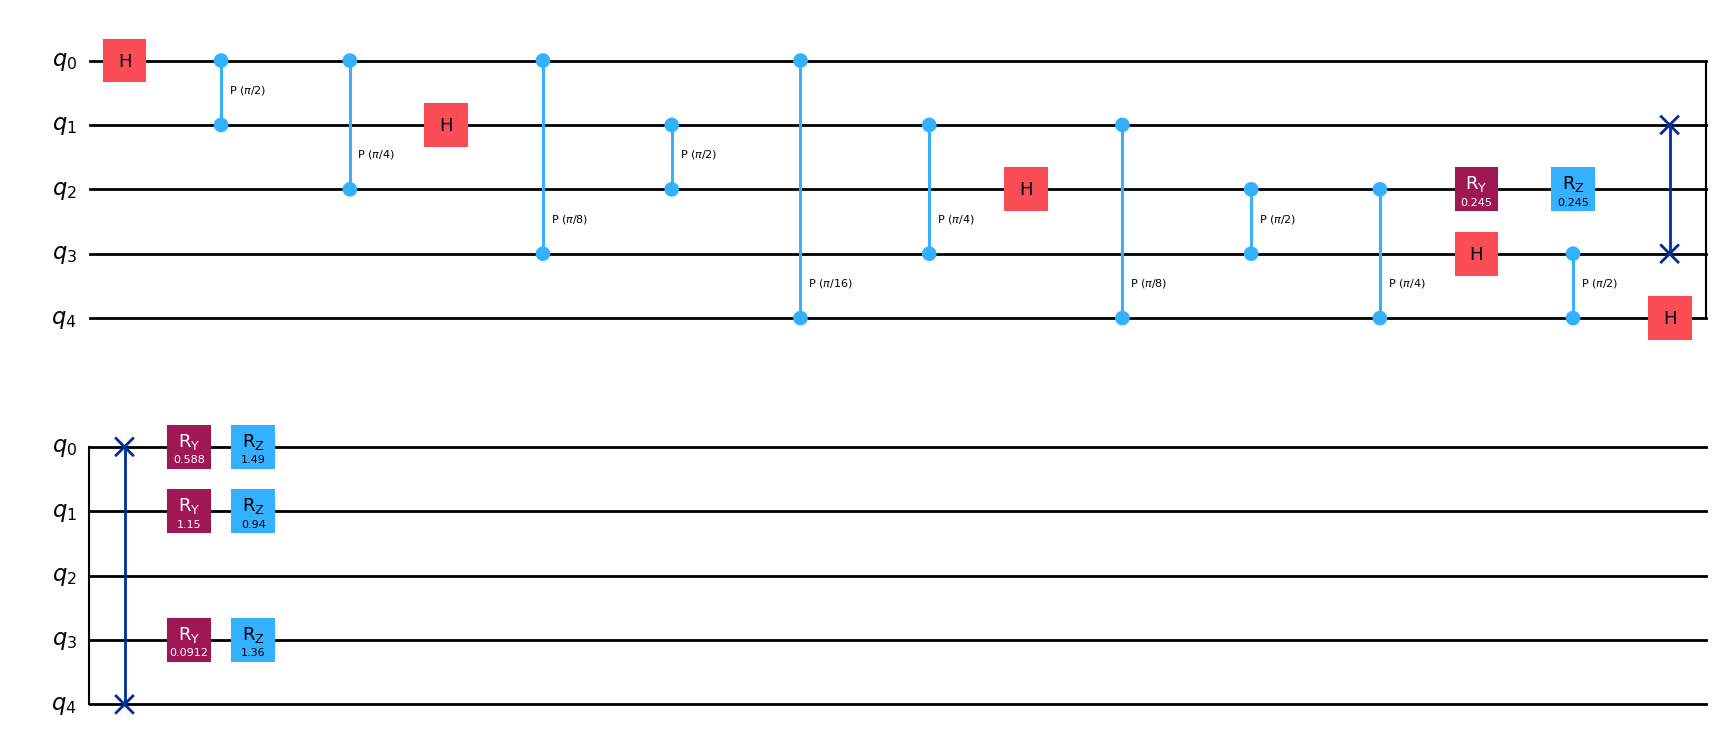

Applied RY(0.94) and RZ(1.11) on qubit 4


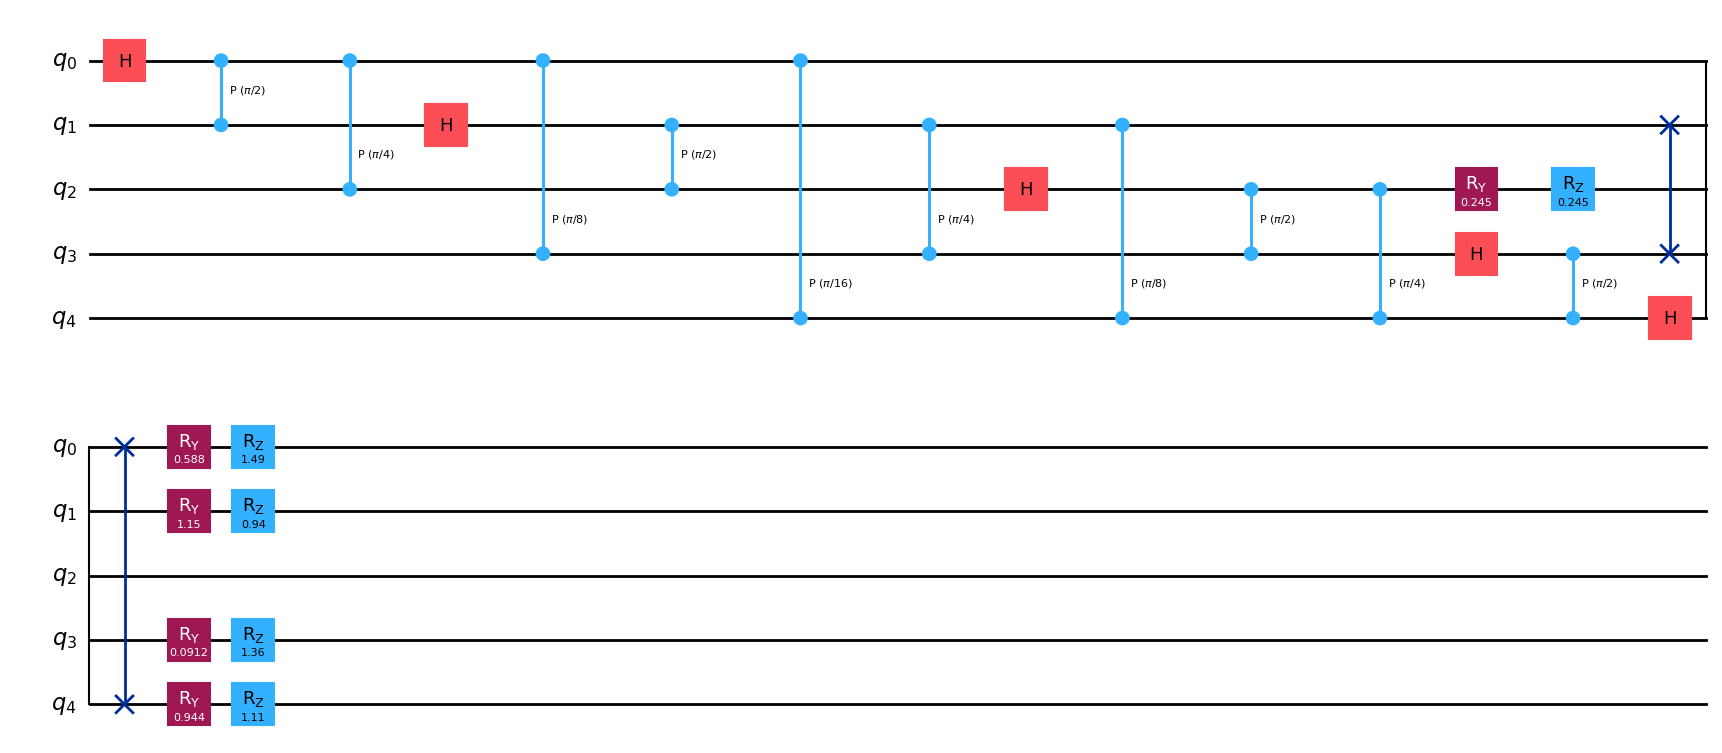

In [6]:
# =========================================================
# Step 5: Optional — Add Random Rotations (for Visualization)
# =========================================================
print("\n=== Step 3: Applying Random RY and RZ Rotations for Benchmarking ===")

# Adding random rotations to visualize more interesting superpositions
np.random.seed(42)  # Fix seed for reproducibility

for i in range(n):
    theta = np.random.uniform(0, np.pi / 2)
    phi = np.random.uniform(0, np.pi / 2)
    qc.ry(theta, i)
    qc.rz(phi, i)
    print(f"Applied RY({theta:.2f}) and RZ({phi:.2f}) on qubit {i}")
    display(qc.draw('mpl'))

    # Show Bloch sphere after each random rotation
    state = Statevector.from_instruction(qc)
    plot_bloch_multivector(state)
    plt.show()



=== Step 4: Final 5-Qubit Quantum State After QFT ===


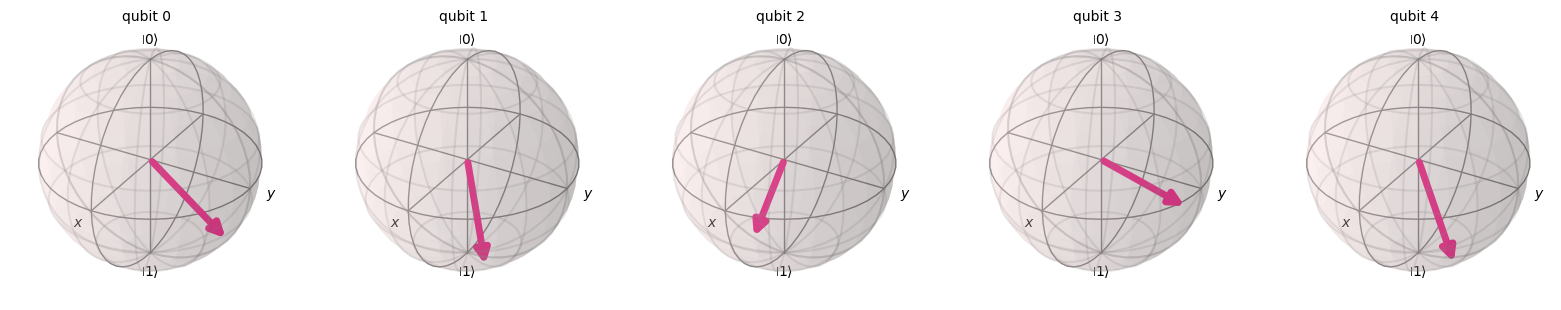

In [8]:
# =========================================================
# Step 6: Final Quantum State Visualization
# =========================================================
print("\n=== Step 4: Final 5-Qubit Quantum State After QFT ===")
state_final = Statevector.from_instruction(qc)
plot_bloch_multivector(state_final)

In [9]:
# Step 7: Summary
print("\n=== Summary ===")
print("1. Quantum Fourier Transform applied successfully to 5 qubits.")
print("2. Each qubit underwent Hadamard + Controlled Phase rotations.")
print("3. SWAP gates were used to reverse the qubit order at the end.")
print("4. Random RY and RZ rotations added for visualization purposes.")
print("5. Bloch sphere plots show how the quantum state evolved at each step.")


=== Summary ===
1. Quantum Fourier Transform applied successfully to 5 qubits.
2. Each qubit underwent Hadamard + Controlled Phase rotations.
3. SWAP gates were used to reverse the qubit order at the end.
4. Random RY and RZ rotations added for visualization purposes.
5. Bloch sphere plots show how the quantum state evolved at each step.
